# Bifircacion de tridente subcritica

Su forma normal es: $\dot x = rx + x^3$

Si buscamos los puntos de equilibrio, tenemos que:

$$
0 = rx^* + {x^*}^3 = x^*(r+{x^*}^2)
$$

por lo que $x^*=0$ siempre es punto de equilibrio

Ahora, notemos que:

Si $r < 0$

hay 3 soluciones de equilibrio, que son $x_1^* = 0 \quad x_2^*=\sqrt{-r} \quad x_3^{*} = -\sqrt{-r}$ pero

Si $r\geq 0$ solo tenemos una solucion de equilibrio que es $x^*=0$

Veamos como son sus estabilidades, Como $f(x) = rx + x^3$ entonces:

$$
f'(x) = r + 3x^2,
$$

por lo cual:

$$
f'(0) = r \quad y \quad f'(\pm \sqrt{-r}) = r + 3(-r) = -2r.
$$

De donde, podemos decir que:

Si $r>0$, Solo tenemos 1 punto de equilibrio y es $x^*=0$ y como $f'(0) = r$

Si $r=0$, Solo tenemos 1 punto de equilibrio que es $x^*=0$ pero en este caso, como $f'(0)=0$ no podemos decir nada acerca de su estabilidad y 

si $r<0$, Tenemos 3 puntos de quilibrio que son $x_1^* = 0 \quad x_2^*=\sqrt{-r} \quad x_3^{*} = -\sqrt{-r}$ y como $f'(0) = r$ y $f'(\pm \sqrt{-r}) = r + 3(-r) = -2r$

Tenemos que $x_1^*=0$ es estable pero $x_{2,3}^*=\pm \sqrt{-r}$ son inestables


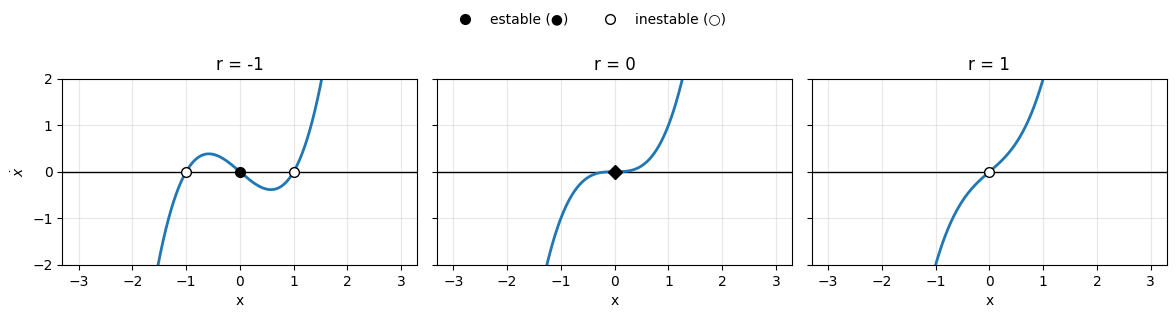

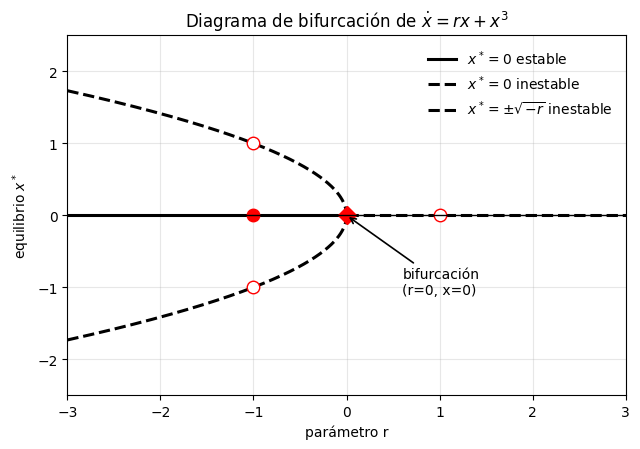

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, r):
    return r*x + x**3

def fp(x, r):
    return r + 3*x**2

def equilibria(r):
    eq = [0.0]
    if r < 0:
        a = np.sqrt(-r)
        eq += [-a, a]
    return sorted(eq)

# ---------- FIGURA 1: 3 graficas xdot vs x ----------
def plot_tres_graficas(rs=(-1, 0, 1), xlim=3.0, ylim_dx=(-2, 2), tol=1e-10):
    x = np.linspace(-xlim, xlim, 800)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)

    handles = {"estable": None, "inestable": None, "nohip": None}

    for ax, r in zip(axes, rs):
        ax.axhline(0, color="k", lw=1)
        ax.plot(x, f(x, r), lw=2)

        for xe in equilibria(r):
            d = fp(xe, r)
            if abs(d) < tol:
                h = ax.plot([xe], [0], marker="D", ms=7, linestyle="None", color="k")[0]
                if handles["nohip"] is None: handles["nohip"] = h
            elif d < 0:
                h = ax.plot([xe], [0], marker="o", ms=7, linestyle="None",
                            markerfacecolor="k", markeredgecolor="k")[0]
                if handles["estable"] is None: handles["estable"] = h
            else:
                h = ax.plot([xe], [0], marker="o", ms=7, linestyle="None",
                            markerfacecolor="white", markeredgecolor="k")[0]
                if handles["inestable"] is None: handles["inestable"] = h

        ax.set_title(f"r = {r}")
        ax.set_xlabel("x")
        ax.set_ylim(*ylim_dx)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"$\dot x$")

    fig.legend([handles["estable"], handles["inestable"]],
               ["estable (●)", "inestable (○)"],
               loc="upper center", ncol=3, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.88])
    return fig

# ---------- FIGURA 2: diagrama de bifurcacion ----------
def plot_diagrama_bifurcacion(rs=(-1, 0, 1), r_min=-3.0, r_max=3.0, tol=1e-10):
    r_neg = np.linspace(r_min, 0, 800)  # r<0
    r_pos = np.linspace(0, r_max, 800)  # r>0

    fig, ax = plt.subplots(figsize=(6.5, 4.6))

    # x*=0: estable si r<0, inestable si r>0
    ax.plot(r_neg, 0*r_neg, "k-",  lw=2.2, label=r"$x^*=0$ estable")
    ax.plot(r_pos, 0*r_pos, "k--", lw=2.2, label=r"$x^*=0$ inestable")

    # x*=±sqrt(-r): r<0 (inestables)
    xb = np.sqrt(-r_neg)
    ax.plot(r_neg,  xb, "k--", lw=2.2, label=r"$x^*=\pm\sqrt{-r}$ inestable")
    ax.plot(r_neg, -xb, "k--", lw=2.2)

    # Punto no hiperbólico (0,0)
    ax.plot([0], [0], marker="D", ms=8, linestyle="None", color="k")
    ax.annotate("bifurcación\n(r=0, x=0)", xy=(0, 0), xytext=(0.6, -1.1),
                arrowprops=dict(arrowstyle="->", lw=1.2))

    # Marcar r=-1,0,1 en rojo con estabilidad
    for r in rs:
        for xe in equilibria(r):
            d = fp(xe, r)
            if abs(d) < tol:
                ax.plot([r], [xe], marker="D", ms=9, linestyle="None", color="red")
            elif d < 0:
                ax.plot([r], [xe], marker="o", ms=9, linestyle="None",
                        markerfacecolor="red", markeredgecolor="red")
            else:
                ax.plot([r], [xe], marker="o", ms=9, linestyle="None",
                        markerfacecolor="white", markeredgecolor="red")

    ax.axhline(0, color="k", lw=1)
    ax.set_xlim(r_min, r_max)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel("parámetro r")
    ax.set_ylabel(r"equilibrio $x^*$")
    ax.set_title(r"Diagrama de bifurcación de $\dot x = r x + x^3$")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.0, 1.0))


    fig.tight_layout()
    return fig

# --- Llamadas (muestran 2 figuras separadas) ---
plot_tres_graficas();
plot_diagrama_bifurcacion();


**Ejemplo:**

$$
\dot{x} = x - \beta \tanh(x).
$$

Sabemos que $\tanh(0) = 0$.

Así, $x^* = 0$ es solución de equilibrio.

Llevando a la forma normal por expansión en series de Taylor.

$$
\tanh(0) = 0.
$$

Calculamos la derivada:

$$
\frac{d}{dx}\tanh(x)
= \frac{d}{dx}\left(\frac{e^x - e^{-x}}{e^x + e^{-x}}\right)
= \frac{\cosh^2(x) + \sinh^2(x)}{\cosh^2(x)}.
$$

Por lo tanto,

$$
\frac{d}{dx}\tanh(x) = 1 + \tanh^2(x)\quad \text{de donde,}\quad\frac{d}{dx}\tanh(0) = 1
$$

Calculamos derivadas de $\tanh$:

$$
\frac{d^2}{dx^2}\tanh(x)
= 2\tanh(x)\frac{d}{dx}\tanh(x)\quad\text{Asi mismo,}\quad\frac{d^2}{dx^2}\tanh(0) = 0
$$

La tercera derivada es

$$
\frac{d^3}{dx^3}\tanh(x)
= 2\tanh(x)\frac{d^2}{dx^2}\tanh(x)
+ 2\left(\frac{d}{dx}\tanh(x)\right)^2\quad\text{de igual forma}\quad\frac{d^3}{dx^3}\tanh(0) = 2
$$

Así, la expansión de Taylor es

$$
\tanh(x) \approx x + \frac{2}{3!}x^3.
$$

Sustituyendo en la ecuación,

$$
\dot{x} \approx x - \beta\left(x + \frac{1}{3}x^3\right)
= (1-\beta)x + \frac{\beta}{3}x^3.
$$

Haciendo el cambio de variable

$$
y = \frac{\beta}{3}x,\quad \dot{y}=\frac{\beta}{3}\dot{x}
$$

y multiplicando por $\displaystyle\frac{\beta}{3}$, se obtiene que

$$
\frac{\beta^2}{3}\dot{x}
= \frac{\beta^2}{3}(1-\beta)x + x\left(\frac{\beta}{3}x\right)^3,
$$

o equivalentemente,

$$
\frac{\beta}{3}\dot{y}
= \frac{\beta}{3}(1-\beta)y + y^3.
$$

$$
\dot{y}
= \frac{3(1-\beta)}{\beta}\, y
- \frac{3}{\beta}\, y^3.
$$

Calculamos la derivada en $y=0$:

$$
\left.\frac{d\dot{y}}{dy}\right|_{0}
= \frac{3(1-\beta)}{\beta}
- \frac{3}{\beta}\, 3y^2
= \frac{3(1-\beta)}{\beta}.
$$

por lo tanto, En $x^*=0$

Si $\beta > 0$:

- Si $\beta > 1$, el equilibrio es **estable**.
- Si $\beta < 1$, el equilibrio es **inestable**.



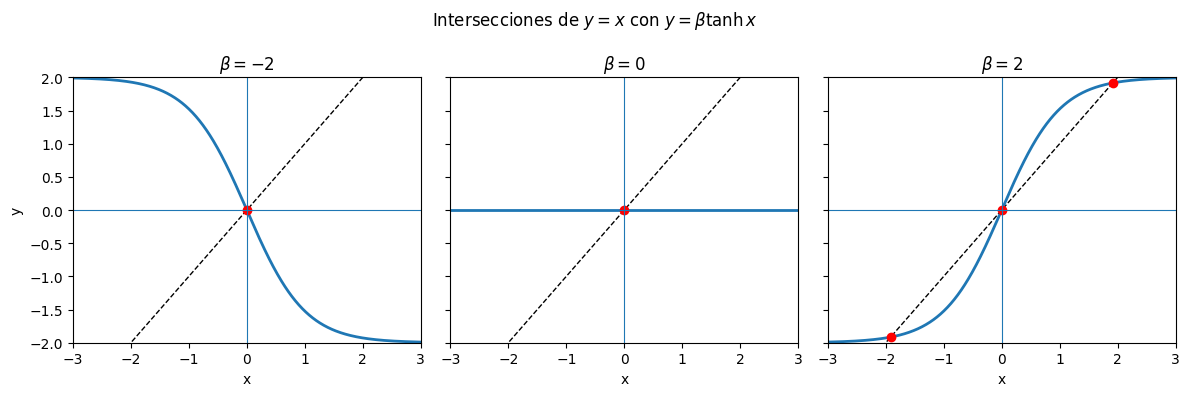

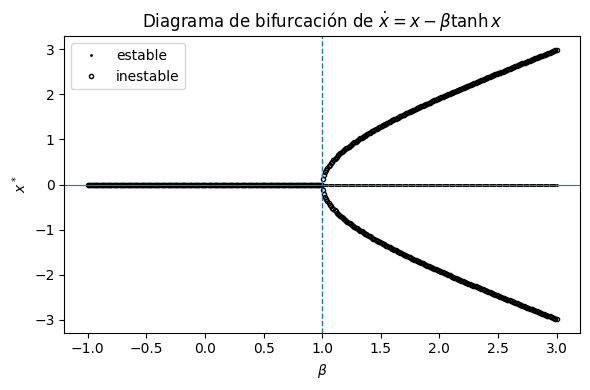

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# =========================
# FIGURA 1: INTERSECCIONES
# =========================

x = np.linspace(-3, 3, 600)
betas_plot = [-2, 0, 2]

fig1, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

for ax, beta in zip(axes, betas_plot):

    # Curvas
    ax.plot(x, x, 'k--', linewidth=1)
    ax.plot(x, beta * np.tanh(x), linewidth=2)

    # Función
    def f(z):
        return z - beta * np.tanh(z)

    # Buscar intersecciones
    seeds = [-2, 0, 2]
    roots = set()

    for s in seeds:
        try:
            r = fsolve(f, s)[0]
            if abs(f(r)) < 1e-6:
                roots.add(np.round(r, 3))
        except:
            pass

    # Puntos de equilibrio
    for r in roots:
        ax.plot(r, r, 'ro')

    # Ejes
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(rf"$\beta = {beta}$")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-2, 2)
    ax.set_xlabel("x")

axes[0].set_ylabel("y")
fig1.suptitle(r"Intersecciones de $y=x$ con $y=\beta\tanh x$", fontsize=12)
plt.tight_layout()
plt.show()


# =========================
# FIGURA 2: DIAGRAMA DE BIFURCACIÓN
# =========================

betas = np.linspace(-1, 3, 400)
seeds = [-3, -1, 0, 1, 3]

beta_stable, x_stable = [], []
beta_unstable, x_unstable = [], []

for beta in betas:

    def f(x):
        return x - beta * np.tanh(x)

    def df(x):
        return 1 - beta * (1 / np.cosh(x))**2

    roots = set()

    for s in seeds:
        try:
            r = fsolve(f, s)[0]
            if abs(f(r)) < 1e-6:
                roots.add(np.round(r, 4))
        except:
            pass

    for r in roots:
        if df(r) < 0:
            beta_stable.append(beta)
            x_stable.append(r)
        else:
            beta_unstable.append(beta)
            x_unstable.append(r)

plt.figure(figsize=(6, 4))

plt.plot(beta_stable, x_stable, 'k.', markersize=2, label="estable")
plt.plot(beta_unstable, x_unstable, 'ko', markersize=3,
         fillstyle='none', label="inestable")

plt.axhline(0, linewidth=0.8)
plt.axvline(1, linestyle='--', linewidth=1)

plt.xlabel(r"$\beta$")
plt.ylabel(r"$x^*$")
plt.title(r"Diagrama de bifurcación de $\dot x = x - \beta\tanh x$")
plt.legend()
plt.tight_layout()
plt.show()
